## tensorflow 手寫辨識練習
https://colab.research.google.com/drive/1joG2EWxQbmOSd3ftPKP-W4X3lUI-S0SY?usp=sharing

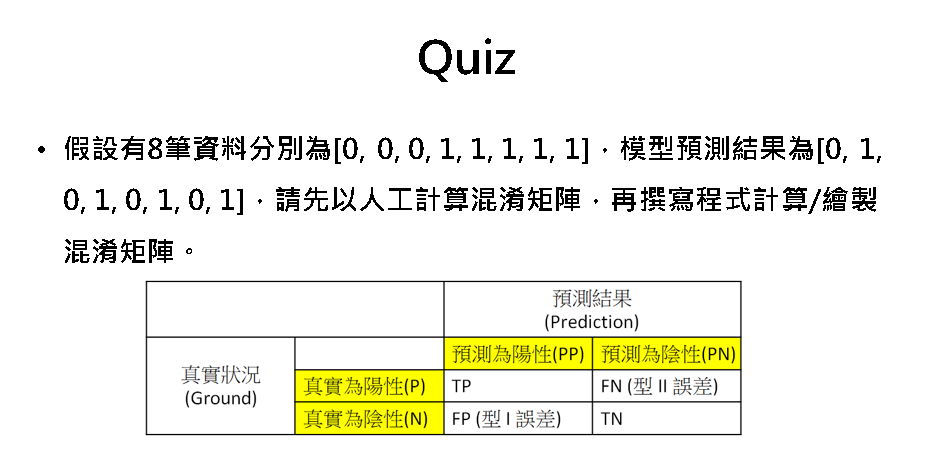

In [1]:
y_true = [0, 0, 0, 1, 1, 1, 1, 1]
y_pred = [0, 1, 0, 1, 0, 1, 0, 1]

In [2]:
from sklearn.metrics import confusion_matrix


In [4]:
confusion_matrix(y_true,y_pred)

array([[2, 1],
       [2, 3]], dtype=int64)

In [5]:
confusion_matrix(y_true,y_pred,labels=[1,0])

array([[3, 2],
       [1, 2]], dtype=int64)

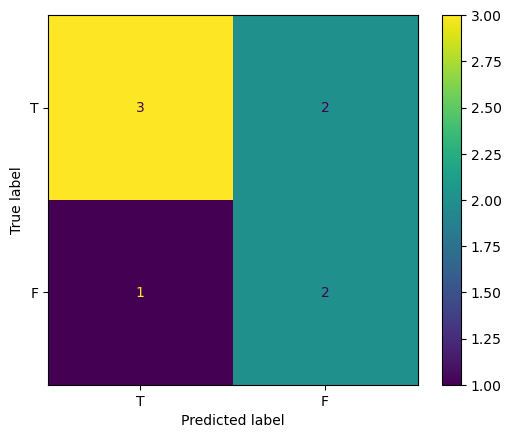

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_predictions(y_true,y_pred,labels=[1,0],display_labels=["T","F"])

### 準確率 (Accuracy)
表示模型正確預測的案例（真陽性和真陰性）占所有案例的比例。公式如下：
$$ \text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN} $$

### 精確率 (Precision)我要找到更多精準找到陽性的人 但可能抓錯人
表示被模型預測為陽性且實際上也為陽性的案例占所有被模型預測為陽性的案例的比例。公式如下：

降低假陽(FP)我提高了病毒的量 並度量要高才算陽 但是有些少量病毒的也因該是陽性所以FN上升
$$ \text{Precision} = \frac{TP}{TP + FP} $$

### 召回率 (Recall) 或稱敏感度 (Sensitivity) 我要找到更多陽性的人
表示被模型預測為陽性且實際上也為陽性的案例占所有實際陽性案例的比例。公式如下：

降低假英(FN)我降低了病毒的量 但是有些少量病毒就算陽 但是這要FP(假陽就可能上升)
$$ \text{Recall} = \frac{TP}{TP + FN} $$

## 精確率 與 召回率 此消彼漲
FP想變小FN有可能多 FN想變小FP可能多這就是 消彼長的關係原因

### F1 Score
為精確率與召回率的調和平均數，是兩者之間的平衡。公式如下：
$$ \text{F1 Score} = \frac{2 \times TP}{2 \times TP + FP + FN} $$

# 羅吉斯迴歸（Logistic Regression）

### 適合二分法


- e很大X越靠近0

- e很小X越無限大

In [7]:
import numpy as np
for x in range(-10,11):
    print(x,np.exp(-x))

-10 22026.465794806718
-9 8103.083927575384
-8 2980.9579870417283
-7 1096.6331584284585
-6 403.4287934927351
-5 148.4131591025766
-4 54.598150033144236
-3 20.085536923187668
-2 7.38905609893065
-1 2.718281828459045
0 1.0
1 0.36787944117144233
2 0.1353352832366127
3 0.049787068367863944
4 0.01831563888873418
5 0.006737946999085467
6 0.0024787521766663585
7 0.0009118819655545162
8 0.00033546262790251185
9 0.00012340980408667956
10 4.5399929762484854e-05


In [8]:
import numpy as np

# 定義羅吉斯函數
def logistic_function(x):
    return 1 / (1 + np.exp(-x))

# 計算範圍從 -10 到 10 的羅吉斯函數值
x_values = np.linspace(-10, 10, 21)  # 產生從 -10 到 10 的21個點
logistic_values = logistic_function(x_values)

# 輸出結果
list(zip(x_values, logistic_values))

[(-10.0, 4.5397868702434395e-05),
 (-9.0, 0.00012339457598623172),
 (-8.0, 0.0003353501304664781),
 (-7.0, 0.0009110511944006454),
 (-6.0, 0.0024726231566347743),
 (-5.0, 0.0066928509242848554),
 (-4.0, 0.01798620996209156),
 (-3.0, 0.04742587317756678),
 (-2.0, 0.11920292202211755),
 (-1.0, 0.2689414213699951),
 (0.0, 0.5),
 (1.0, 0.7310585786300049),
 (2.0, 0.8807970779778823),
 (3.0, 0.9525741268224334),
 (4.0, 0.9820137900379085),
 (5.0, 0.9933071490757153),
 (6.0, 0.9975273768433653),
 (7.0, 0.9990889488055994),
 (8.0, 0.9996646498695336),
 (9.0, 0.9998766054240137),
 (10.0, 0.9999546021312976)]

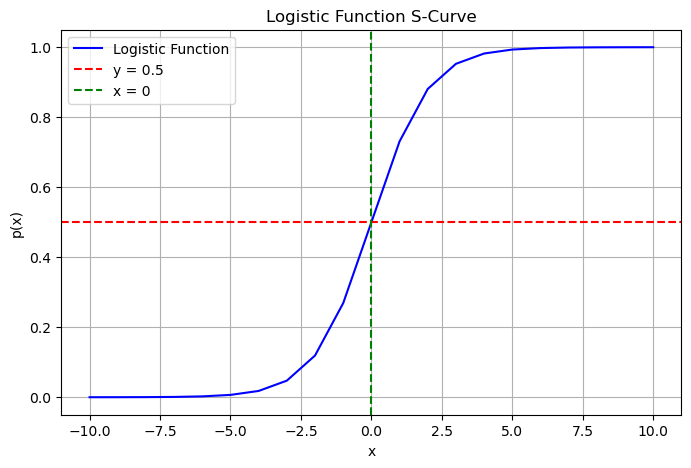

In [9]:
import matplotlib.pyplot as plt

# 使用上一步計算的數據來繪製羅吉斯函數的圖
plt.figure(figsize=(8, 5))
plt.plot(x_values, logistic_values, label='Logistic Function', color='blue')
plt.title('Logistic Function S-Curve')
plt.xlabel('x')
plt.ylabel('p(x)')
plt.grid(True)
plt.axhline(y=0.5, color='r', linestyle='--', label='y = 0.5')
plt.axvline(x=0, color='g', linestyle='--', label='x = 0')
plt.legend()
plt.show()

## 數據

一項實驗對5000名參與者進行了研究，以研究年齡和身體健康對聽力損失，特別是對聽到高音頻聲音的影響。這些數據顯示了研究的結果，參與者被評估並獲得身體能力分數，然後進行音頻測試（通過/不通過），以評估他們聽到高頻聲音的能力。同時記錄了參與者的年齡。是否有可能根據參與者的特徵（年齡和身體分數）建立一個模型來預測某人聽到高頻聲音的可能性？

* 特徵

    * age - 參與者的年齡（以年為單位）
    * physical_score - 身體測試中獲得的分數

* 標籤/目標

    * test_result - 如果未通過，則為0；如果通過測試，則為1

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()

In [11]:
df = pd.read_csv("./hearing_test.csv")
df.head()

,age,physical_score,test_result
0,33.0,40.7,1
1,50.0,37.2,1
2,52.0,24.7,0
3,56.0,31.0,0
4,35.0,42.9,1


In [12]:
df2 = df.sort_values(by="age",ascending=False)
df2[df2["test_result"] == 1]

,age,physical_score,test_result
1075,71.0,28.4,1
3693,71.0,31.9,1
4428,69.0,30.9,1
3407,68.0,33.0,1
3895,68.0,28.6,1
...,...,...,...
2268,22.0,41.8,1
454,22.0,49.5,1
1187,21.0,46.5,1
3196,21.0,46.3,1


In [13]:
df.describe()

,age,physical_score,test_result
count,5000.000000,5000.000000,5000.000000
mean,51.609000,32.760260,0.600000
std,11.287001,8.169802,0.489947
min,18.000000,-0.000000,0.000000
25%,43.000000,26.700000,0.000000
50%,51.000000,35.300000,1.000000
75%,60.000000,38.900000,1.000000
max,90.000000,50.000000,1.000000


In [14]:
df["test_result"].value_counts()

test_result
1    3000
0    2000
Name: count, dtype: int64

<Axes: xlabel='age', ylabel='physical_score'>

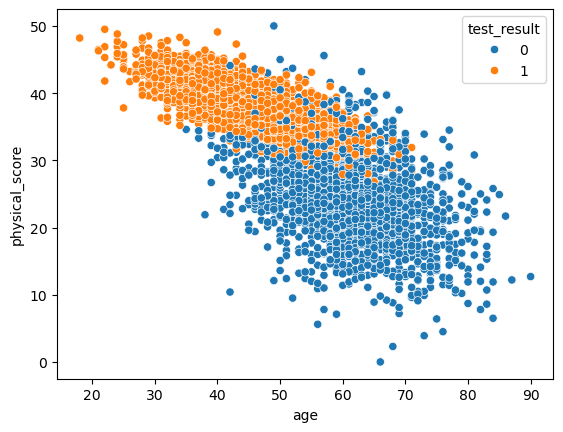

In [15]:
sns.scatterplot(x="age",y="physical_score",data=df,hue="test_result")

<Axes: >

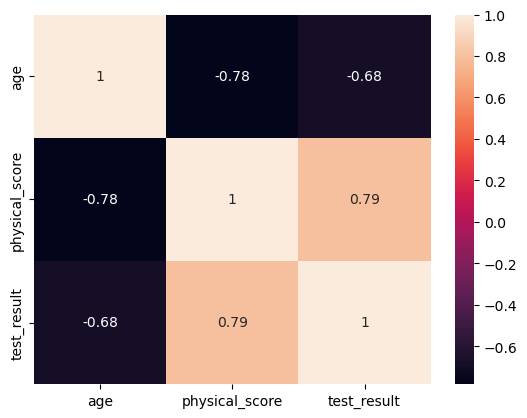

In [16]:
sns.heatmap(df.corr(),annot=True)

In [17]:
X = df.drop("test_result",axis=1)
y = df["test_result"]

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)


In [19]:
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

In [20]:
log_model.fit(scaled_X_train,y_train)

LogisticRegression()

In [21]:
from sklearn.metrics import accuracy_score, classification_report

In [22]:
y_pred =log_model.predict(scaled_X_test)
accuracy_score(y_test,y_pred)

0.93

In [23]:
print(classification_report(y_test,y_pred))
#準確率 (Accuracy)
#精確率 (Precision)
#召回率 (Recall) 

              precision    recall  f1-score   support

           0       0.92      0.89      0.91       193
           1       0.93      0.95      0.94       307

    accuracy                           0.93       500
   macro avg       0.93      0.92      0.93       500
weighted avg       0.93      0.93      0.93       500



# Multi-Class Logistic Regression


In [24]:
df = pd.read_csv("./iris.csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [25]:
X = df.drop("species",axis=1)
y = df["species"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1,random_state=101)
scaler = StandardScaler()
scaled_X_train  = scaler.fit_transform(X_train)
scaled_X_test  = scaler.transform(X_test)

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.multiclass import OneVsRestClassifier#分類問題轉化為多個二元分類問題
#saga 才可使用l1 l2
log_mod = LogisticRegression(solver="saga",max_iter=5000)
oneVsRest_model =  OneVsRestClassifier(log_mod)

In [27]:
penalty = ["l1","l2"]
"""
0 表示10^0 = 1 開始
4 表示10^4 = 10000 結束
10 分10斷
指數範圍從10^0 到 10^4平均切10個點
"""
C = np.logspace(0,4,10)
print(C)
#C 越小，正則化強度越大
grid_model = GridSearchCV(oneVsRest_model, param_grid={'estimator__C': C,
                                                  'estimator__penalty': penalty})
grid_model.fit(scaled_X_train,y_train)

[1.00000000e+00 2.78255940e+00 7.74263683e+00 2.15443469e+01
 5.99484250e+01 1.66810054e+02 4.64158883e+02 1.29154967e+03
 3.59381366e+03 1.00000000e+04]


GridSearchCV(estimator=OneVsRestClassifier(estimator=LogisticRegression(max_iter=5000,
                                                                        solver='saga')),
             param_grid={'estimator__C': array([1.00000000e+00, 2.78255940e+00, 7.74263683e+00, 2.15443469e+01,
       5.99484250e+01, 1.66810054e+02, 4.64158883e+02, 1.29154967e+03,
       3.59381366e+03, 1.00000000e+04]),
                         'estimator__penalty': ['l1', 'l2']})

In [28]:
y_pred = grid_model.predict(scaled_X_test)
accuracy_score(y_test,y_pred)

1.0